# Improve Train

## Package Import and Path Settings

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import hashlib
from pathlib import Path
from collections import defaultdict
import time
from PIL import Image, UnidentifiedImageError
import gc

# pytorch
from torchvision.datasets import ImageFolder
from torch.utils.data import Subset
from torch.utils.data import DataLoader
from torchvision import transforms
from torch import nn
import torch

# models
from torchvision.models import (
    resnet18, ResNet18_Weights, resnet,
    efficientnet_b0, EfficientNet_B0_Weights, efficientnet
)

# data split
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold

# baseline models
from sklearn.dummy import DummyClassifier
from sklearn.metrics import log_loss

# training utils
from src.training import load_checkpoint, get_last_checkpoint, get_last_checkpoint, save_checkpoint
from src.training import CVTrainer

# others
from concurrent.futures import ThreadPoolExecutor
from src.dataset import load_filtered_imagefolder, rgba_to_rgb_with_bg, ds_test_split
from tqdm.auto import tqdm
from src.utils import plot_hist, plot_confusion_matrix_and_report, display_model_info

# path settings
from src import MODELS_DIR, PARAMS_PATH, SEED, PET_IMAGES_DIR, PROJECT_ROOT, get_device
DEVICE = get_device()
CKPT_DIR = PROJECT_ROOT / "outputs" / "checkpoints"
print(f'Device: {DEVICE}')
print(f'MODELS_DIR: {MODELS_DIR}')
print(f'PARAMS_PATH: {PARAMS_PATH}')
print(f'SEED: {SEED}')
print(f'PET_IMAGES_DIR: {PET_IMAGES_DIR}')
print(f'CKPT_DIR (Check Point): {CKPT_DIR}')

# project constants
label = {0:'cat', 1:'dog'}
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)
SAMPLE_SIZE = 256


Device: cuda
MODELS_DIR: C:\Coding Stuff SSD\Python\kaggle-image-classification-cats_dogs\outputs\models
PARAMS_PATH: C:\Coding Stuff SSD\Python\kaggle-image-classification-cats_dogs\outputs\params
SEED: 37
PET_IMAGES_DIR: C:\Coding Stuff SSD\Python\kaggle-image-classification-cats_dogs\data\raw\PetImages
CKPT_DIR (Check Point): C:\Coding Stuff SSD\Python\kaggle-image-classification-cats_dogs\outputs\checkpoints


## Helper Functions



In [18]:
def count_params(module):
    total = sum(p.numel() for p in module.parameters())
    trainable = sum(p.numel() for p in module.parameters() if p.requires_grad)
    return total, trainable


def summarize_top_sections(model):
    print(f"{'name':20s} {'type':25s} {'total_params':>15s} {'trainable':>15s}")
    print("-" * 80)
    for name, module in model.named_children():
        total, trainable = count_params(module)
        print(f"{name:20s} {module.__class__.__name__:25s} {total:15,d} {trainable:15,d}")

def summarize_children(module):
    print(f"{'name':20s} {'type':25s} {'total_params':>15s} {'trainable':>15s}")
    print("-" * 80)
    for name, child in module.named_children():
        total, trainable = count_params(child)
        print(f"{name:20s} {child.__class__.__name__:25s} {total:15,d} {trainable:15,d}")

## Data Loading


Only training transform and data path initialization here, as dataset should be created separately for each model's `weights.transform()`

In [6]:
# training transform
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(SAMPLE_SIZE),    
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# data path
bad_path = PET_IMAGES_DIR / 'bad_files.json'
dup_group_path = PET_IMAGES_DIR / 'duplicate_groups_exact.json'
ignore_path = PET_IMAGES_DIR / 'ignore_files_list.json'

## Transfer Learning Models
**Candidates**
* ResNet18
* EfficientNet-B0

### ResNet18

##### Model Initialization and Data Loading

In [44]:
class ResNet18_Clf(ResNet):
    def __init__(self, num_classes=2, train_mods=None):
        super().__init__(block=resnet.BasicBlock, layers=[2, 2, 2, 2])
        resnet_18_weights = ResNet18_Weights.DEFAULT
        state_dict = resnet_18_weights.get_state_dict(progress=True, check_hash=True)
        self.load_state_dict(state_dict)
        in_features = self.fc.in_features        
        self.fc = nn.Linear(in_features, num_classes)
        if train_mods:
            for m in self.modules():
                for p in m.parameters():
                    p.requires_grad = False
            for s in train_mods:
                module = self.get_submodule(s)
                for p in module.parameters():
                    p.requires_grad = True
    
    @ torch.inference_mode()
    def predict_logits(self, x):
        self.eval()
        return self(x)
    
    @ torch.inference_mode()
    def predict_proba(self, x):
        self.eval()        
        return torch.softmax(self.predict_logits(x), dim=1, dtype=torch.float32)
    
    @ torch.inference_mode()
    def predict(self, x):
        self.eval()
        proba = self.predict_proba(x)        
        return torch.argmax(proba, dim=1)   



In [65]:
  
model_rb18 = ResNet18_Clf(2, ['fc', 'layer4'])
val_tf = ResNet18_Weights.DEFAULT.transforms()
summarize_top_sections(model_rb18)
display_model_info(model_rb18)

name                 type                         total_params       trainable
--------------------------------------------------------------------------------
conv1                Conv2d                              9,408               0
bn1                  BatchNorm2d                           128               0
relu                 ReLU                                    0               0
maxpool              MaxPool2d                               0               0
layer1               Sequential                        147,968               0
layer2               Sequential                        525,568               0
layer3               Sequential                      2,099,712               0
layer4               Sequential                      8,393,728       8,393,728
avgpool              AdaptiveAvgPool2d                       0               0
fc                   Linear                              1,026           1,026
Trainable parameters: 8394754
Model size: 42.68 MB

In [ ]:
ds_aug, excl_set = load_filtered_imagefolder(PET_IMAGES_DIR, bad_path, dup_group_path, ignore_path, train_tf, rgba_to_rgb_with_bg) # the dataset with augmentation
ds, _ = load_filtered_imagefolder(PET_IMAGES_DIR, bad_path, dup_group_path, ignore_path, val_tf, rgba_to_rgb_with_bg) # the dataset without any augmentation

print(f'Dataset Loaded from {PET_IMAGES_DIR}')
print(f'Number of valid samples: {len(ds)}')
print(f'Number of samples excluded: {len(excl_set)}')

idx_train, idx_test, y_train, y_test = ds_test_split(ds, 0.5, SEED, True)

#### Cross Validation

In [49]:
optim = torch.optim.Adam
loss_fn_cls = torch.nn.CrossEntropyLoss
n_split = 5
skf = StratifiedKFold(n_splits=n_split)
epochs = 5

cv_trainer_rb18 = CVTrainer(
    model_cls=ResNet18_Clf,
    model_params={'num_classes': 2, 'train_mods': ['fc', 'layer4']},
    idx_train=idx_train,
    y_train=y_train,
    ds=ds,
    ds_aug=ds_aug,
    splitter=skf,
    split_groups=None,
    device=DEVICE,
    loss_fn_factory=loss_fn_cls,
    optimizer_cls=optim,
    optimizer_params={}    
)

In [51]:
epochs = 5
tr_bs = 64
val_bs = 64
tr_nw = 4
val_nw = 4
hist, oof_y_pred = cv_trainer_rb18.train(epochs=epochs, val_bs=val_bs, tr_bs=tr_bs, tr_nw=tr_nw, val_nw=val_nw)

CV folds:   0%|          | 0/5 [00:00<?, ?it/s]

fold 1 train e1:   0%|          | 0/157 [00:20<?, ?it/s]

fold 1 val e1:   0%|          | 0/40 [00:19<?, ?it/s]

fold 1 train e2:   0%|          | 0/157 [00:00<?, ?it/s]

fold 1 val e2:   0%|          | 0/40 [00:00<?, ?it/s]

...

fold 5 train e4:   0%|          | 0/157 [00:00<?, ?it/s]

fold 5 val e4:   0%|          | 0/39 [00:00<?, ?it/s]

fold 5 train e5:   0%|          | 0/157 [00:00<?, ?it/s]

fold 5 val e5:   0%|          | 0/39 [00:00<?, ?it/s]

fold 5 oof:   0%|          | 0/39 [00:00<?, ?it/s]

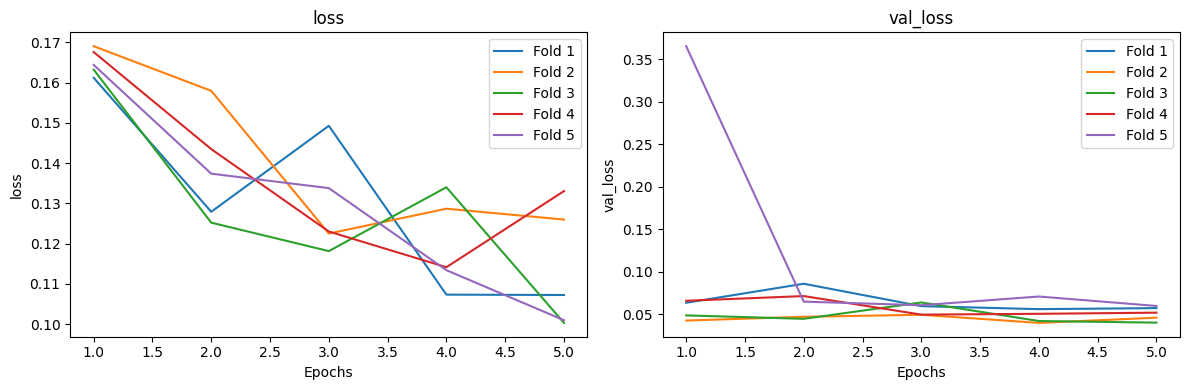

best val loss of fold 1 at epochs : 4, val_loss = 0.05573115773230138
best val loss of fold 2 at epochs : 4, val_loss = 0.039533320925797866
best val loss of fold 3 at epochs : 5, val_loss = 0.039831813808173494
best val loss of fold 4 at epochs : 3, val_loss = 0.049275908408806614
best val loss of fold 5 at epochs : 5, val_loss = 0.05947156646587432
Val loss :0.0488 ± 0.0081
Train loss :0.1090 ± 0.0084


In [52]:
plot_hist(hist)
min_val_losses = []
min_tr_losses = []
for i, f in enumerate(hist):
    print(f'best val loss of fold {i + 1} at epochs : {np.argmin(f['val_loss']) + 1}, val_loss = {np.min(f['val_loss'])}')
    min_val_losses.append(np.min(f['val_loss']))
    min_tr_losses.append(np.min(f['loss']))
print(f'Val loss :{np.mean(min_val_losses):.4f} ± {np.std(min_val_losses):.4f}')
print(f'Train loss :{np.mean(min_tr_losses):.4f} ± {np.std(min_tr_losses):.4f}')

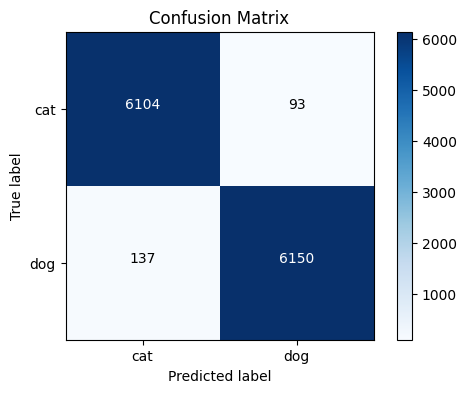

              precision    recall  f1-score   support

         cat       0.98      0.98      0.98      6197
         dog       0.99      0.98      0.98      6287

    accuracy                           0.98     12484
   macro avg       0.98      0.98      0.98     12484
weighted avg       0.98      0.98      0.98     12484



In [53]:
plot_confusion_matrix_and_report(oof_y_pred, y_train, target_names=['cat', 'dog'])

### EfficientNet-B0

##### Model Initialization and Data Loading

In [4]:
class EffNet_B0_Clf(efficientnet.EfficientNet):
    def __init__(self, num_classes=2, train_mods=None):
        inverted_residual_setting, last_channel = efficientnet._efficientnet_conf(
            "efficientnet_b0",
            width_mult=1.0,
            depth_mult=1.0,
        )

        super().__init__(
            inverted_residual_setting=inverted_residual_setting,
            dropout=0.2,
            last_channel=last_channel,
        )

        weights = EfficientNet_B0_Weights.DEFAULT
        state_dict = weights.get_state_dict(progress=True, check_hash=True)
        self.load_state_dict(state_dict)

        in_features = self.classifier[1].in_features
        self.classifier[1] = nn.Linear(in_features, num_classes)
        if train_mods:
            for m in self.modules():
                for p in m.parameters():
                    p.requires_grad = False
            for s in train_mods:
                module = self.get_submodule(s)
                for p in module.parameters():
                    p.requires_grad = True
    
    @ torch.inference_mode()
    def predict_logits(self, x):
        self.eval()
        return self(x)
    
    @ torch.inference_mode()
    def predict_proba(self, x):
        self.eval()        
        return torch.softmax(self.predict_logits(x), dim=1, dtype=torch.float32)
    
    @ torch.inference_mode()
    def predict(self, x):
        self.eval()
        proba = self.predict_proba(x)        
        return torch.argmax(proba, dim=1)   



In [64]:
model_effb0 = EffNet_B0_Clf(2, ['features.7', 'features.8', 'classifier'])
val_tf = EfficientNet_B0_Weights.DEFAULT.transforms()
summarize_top_sections(model_effb0)
display_model_info(model_effb0)

name                 type                         total_params       trainable
--------------------------------------------------------------------------------
features             Sequential                      4,007,548       1,129,392
avgpool              AdaptiveAvgPool2d                       0               0
classifier           Sequential                          2,562           2,562
Trainable parameters: 1131954
Model size: 15.46 MB


In [59]:
ds_aug, excl_set = load_filtered_imagefolder(PET_IMAGES_DIR, bad_path, dup_group_path, ignore_path, train_tf, rgba_to_rgb_with_bg) # the dataset with augmentation
ds, _ = load_filtered_imagefolder(PET_IMAGES_DIR, bad_path, dup_group_path, ignore_path, val_tf, rgba_to_rgb_with_bg) # the dataset without any augmentation

print(f'Dataset Loaded from {PET_IMAGES_DIR}')
print(f'Number of valid samples: {len(ds)}')
print(f'Number of samples excluded: {len(excl_set)}')

idx_train, idx_test, y_train, y_test = ds_test_split(ds, 0.5, SEED, True)

Dataset Loaded from C:\Coding Stuff SSD\Python\kaggle-image-classification-cats_dogs\data\raw\PetImages
Number of valid samples: 24968
Number of samples excluded: 32


#### Cross Validation

In [66]:
optim = torch.optim.Adam
loss_fn_cls = torch.nn.CrossEntropyLoss
n_split = 5
skf = StratifiedKFold(n_splits=n_split)
epochs = 5

cv_trainer_effb0 = CVTrainer(
    model_cls=EffNet_B0_Clf,
    model_params={'num_classes': 2, 'train_mods': ['features.7', 'features.8', 'classifier']},
    idx_train=idx_train,
    y_train=y_train,
    ds=ds,
    ds_aug=ds_aug,
    splitter=skf,
    split_groups=None,
    device=DEVICE,
    loss_fn_factory=loss_fn_cls,
    optimizer_cls=optim,
    optimizer_params={}    
)

In [67]:
epochs = 5
tr_bs = 64
val_bs = 64
tr_nw = 4
val_nw = 4
hist, oof_y_pred = cv_trainer_effb0.train(epochs=epochs, val_bs=val_bs, tr_bs=tr_bs, tr_nw=tr_nw, val_nw=val_nw)

CV folds:   0%|          | 0/5 [00:00<?, ?it/s]

fold 1 train e1:   0%|          | 0/157 [00:28<?, ?it/s]

fold 1 val e1:   0%|          | 0/40 [00:19<?, ?it/s]

fold 1 train e2:   0%|          | 0/157 [00:00<?, ?it/s]

fold 1 val e2:   0%|          | 0/40 [00:00<?, ?it/s]

...

fold 5 train e4:   0%|          | 0/157 [00:00<?, ?it/s]

fold 5 val e4:   0%|          | 0/39 [00:00<?, ?it/s]

fold 5 train e5:   0%|          | 0/157 [00:00<?, ?it/s]

fold 5 val e5:   0%|          | 0/39 [00:00<?, ?it/s]

fold 5 oof:   0%|          | 0/39 [00:00<?, ?it/s]

best val loss of fold 1 at epochs : 5, val_loss = 0.04191070493178499
best val loss of fold 2 at epochs : 3, val_loss = 0.033499941889242886
best val loss of fold 3 at epochs : 3, val_loss = 0.027725599116869913
best val loss of fold 4 at epochs : 3, val_loss = 0.03085698044426592
best val loss of fold 5 at epochs : 4, val_loss = 0.03729537023285117
Val loss :0.0343 ± 0.0050
Train loss :0.0935 ± 0.0027


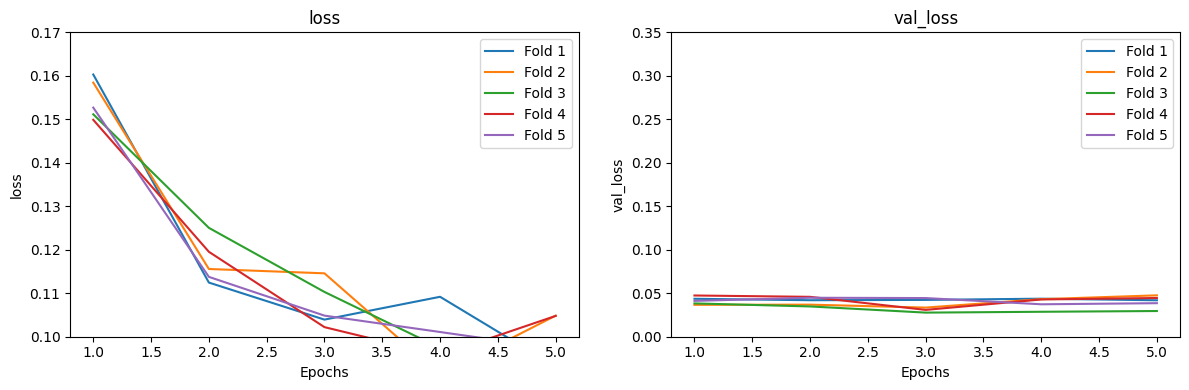

In [77]:
fig, ax = plot_hist(hist, show=False)
ax[0].set_ylim(0.1, 0.17)
ax[1].set_ylim(0, 0.35)
# display(fig)
min_val_losses = []
min_tr_losses = []
for i, f in enumerate(hist):
    print(f'best val loss of fold {i + 1} at epochs : {np.argmin(f['val_loss']) + 1}, val_loss = {np.min(f['val_loss'])}')
    min_val_losses.append(np.min(f['val_loss']))
    min_tr_losses.append(np.min(f['loss']))
print(f'Val loss :{np.mean(min_val_losses):.4f} ± {np.std(min_val_losses):.4f}')
print(f'Train loss :{np.mean(min_tr_losses):.4f} ± {np.std(min_tr_losses):.4f}')

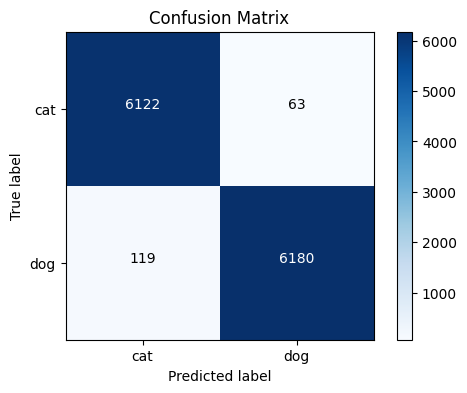

              precision    recall  f1-score   support

         cat       0.98      0.99      0.99      6185
         dog       0.99      0.98      0.99      6299

    accuracy                           0.99     12484
   macro avg       0.99      0.99      0.99     12484
weighted avg       0.99      0.99      0.99     12484



In [78]:
plot_confusion_matrix_and_report(oof_y_pred, y_train, target_names=['cat', 'dog'])

### Conclusion

**Transfer Learning Model Comparison**
| Model           | Mean best val loss |    Std | OOF accuracy | Trainable params | Model size |
| --------------- | -----------------: | -----: | -----------: | ---------------: | ---------: |
| ResNet18        |             0.0488 | 0.0081 |         0.98 |            8.39M |   42.68 MB |
| EfficientNet-B0 |             0.0343 | 0.0050 |         0.99 |            1.13M |   15.46 MB |

`EfficientNet-B0` achieved better performance in a 5-epoch cross-validation training run with a smaller model size. The model is chosen as the final model because it offers the best accuracy-to-size trade-off.

## Final Model Train

* Train the final model with longer epochs
* Report the final performance on test data

### Trainer Preparation

In [ ]:
class Trainer:
    def __init__(self,
        *,
        model: torch.nn.Module,        
        idx_train: list[int] | np.ndarray,
        y_train: list[int] | np.ndarray,
        ds_tr: Subset,
        ds_val: Subset,        
        loss_fn: torch.nn.Module,
        optimizer: torch.optim.Optimizer,        
        device: str | torch.device = "cpu"
        ):
        self.model = model        
        self.idx_train = np.asarray(idx_train)
        self.y_train = np.asarray(y_train)
        self.ds_tr = ds_tr
        self.ds_val = ds_val        
        self.loss_fn = loss_fn
        self.optimizer = optimizer        
        self.device = device
        self.hist: dict[str, list[float]] = {'loss':[], 'val_loss':[]}
    
    def train(
            self,
            epochs: int,
            tr_bs: int,
            val_bs: int | None = None,
            *,
            tr_nw: int = 4,
            val_nw: int = 4,          
            show_progress: bool = True,
            chk_pt_period: int = 20,
            save_chk_pt: bool = False,
            chk_pt_dir: Path
        ):
        if val_bs is None:
            val_bs = tr_bs
        tr_dl = DataLoader(self.ds_tr, tr_bs, shuffle=True, num_workers=tr_nw, persistent_workers=True, pin_memory=True)        
        val_dl = DataLoader(self.ds_val, val_bs, shuffle=False, num_workers=val_nw, persistent_workers=True, pin_memory=True)
        self.model.train()
        epoch_pbar = tqdm(range(epochs), desc='epoch', leave=False)
        for e in epoch_pbar:
            epoch_pbar.set_description(f'epoch {e+1}/{epochs}')
            self.model.train()
            fold_tr_size = 0
            fold_val_size = 0
            total_loss = 0 
            total_val_loss = 0
            for x, y in tqdm(tr_dl, desc=f"train e{e+1}", leave=False):
                x = x.to(self.device, non_blocking=True)
                y = y.to(self.device, non_blocking=True)
                self.optimizer.zero_grad(set_to_none=True)
                logits = self.model(x)            
                loss = self.loss_fn(logits, y.long())
                bs = x.size(0)
                fold_tr_size += bs
                total_loss += loss.item() * bs
                train_loss = total_loss / fold_tr_size
                loss.backward()
                self.optimizer.step()
            self.hist['loss'].append(train_loss)    
            # validation
            self.model.eval()
            with torch.inference_mode():
                for x, y in tqdm(val_dl, desc=f"val e{e+1}", leave=False):
                    x = x.to(self.device, non_blocking=True)
                    y = y.to(self.device, non_blocking=True)
                    logits = self.model(x)
                    loss = self.loss_fn(logits, y.long())
                    bs = x.size(0)
                    fold_val_size += bs
                    total_val_loss += loss.item() * bs
                    val_loss = total_val_loss / fold_val_size    
            self.hist['val_loss'].append(val_loss)
            epoch_pbar.set_postfix(loss=f"{train_loss:.4f}", val_loss=f"{val_loss:.4f}")
            if (e + 1) % chk_pt_period == 0:
                if show_progress:
                    print(f'epoch: {e + 1}: train loss: {train_loss:.4f}, val_loss={val_loss:.4f}')
                if save_chk_pt:
                    timestr = time.strftime("%Y%m%d-%H-%M-%S")
                    ckpt_path = f'ckpt_{timestr}_{e + 1}.pt'                    
                    save_checkpoint(
                        ckpt_path=chk_pt_dir / ckpt_path,
                        model=self.model,
                        optimizer=self.optimizer,
                        epoch=e + 1,
                        hist=self.hist,
                        extra={
                            "seed": SEED,
                            "batch_size": tr_bs,
                            "val_batch_size": val_bs,                            
                        },
                        )
        del tr_dl, val_dl
        pass

### Model Initialization and Data Loading

In [11]:
model_effb0 = EffNet_B0_Clf(2, ['features.7', 'features.8', 'classifier']).to(DEVICE)
val_tf = EfficientNet_B0_Weights.DEFAULT.transforms()

ds_aug, excl_set = load_filtered_imagefolder(PET_IMAGES_DIR, bad_path, dup_group_path, ignore_path, train_tf, rgba_to_rgb_with_bg) # the dataset with augmentation
ds, _ = load_filtered_imagefolder(PET_IMAGES_DIR, bad_path, dup_group_path, ignore_path, val_tf, rgba_to_rgb_with_bg) # the dataset without any augmentation

print(f'Dataset Loaded from {PET_IMAGES_DIR}')
print(f'Number of valid samples: {len(ds)}')
print(f'Number of samples excluded: {len(excl_set)}')

idx_train, idx_test, y_train, y_test = ds_test_split(ds, 0.5, SEED, True)
tr_idx, val_idx, y_tr, y_val = train_test_split(idx_train, y_train, test_size=0.2, random_state=SEED, shuffle=True, stratify=y_train)
ds_train = Subset(ds_aug, tr_idx)
ds_val = Subset(ds, val_idx)



Dataset Loaded from C:\Coding Stuff SSD\Python\kaggle-image-classification-cats_dogs\data\raw\PetImages
Number of valid samples: 24968
Number of samples excluded: 32


In [13]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_effb0.parameters())
epochs = 50
tr_nw = 4
tr_bs = 64
val_nw = 4
val_bs = 64
chk_pt_period = 10

trainer = Trainer(
                model=model_effb0, 
                idx_train=idx_train,
                y_train=y_train,
                ds_tr=ds_train,
                ds_val=ds_val,
                loss_fn=loss_fn,
                optimizer=optimizer,
                device=DEVICE
                )

In [ ]:
trainer.train(epochs=epochs,
              tr_bs=tr_bs,
              val_bs=val_bs,
              tr_nw=tr_nw,
              val_nw=val_nw,
              chk_pt_period=chk_pt_period,
              save_chk_pt=True,
              chk_pt_dir=CKPT_DIR
            )

epoch:   0%|          | 0/50 [00:00<?, ?it/s]

train e1:   0%|          | 0/157 [00:19<?, ?it/s]

val e1:   0%|          | 0/40 [00:19<?, ?it/s]

train e2:   0%|          | 0/157 [00:00<?, ?it/s]

val e2:   0%|          | 0/40 [00:00<?, ?it/s]

...

train e49:   0%|          | 0/157 [00:00<?, ?it/s]

val e49:   0%|          | 0/40 [00:00<?, ?it/s]

train e50:   0%|          | 0/157 [00:00<?, ?it/s]

val e50:   0%|          | 0/40 [00:00<?, ?it/s]

epoch: 50: train loss: 0.0546, val_loss=0.0386


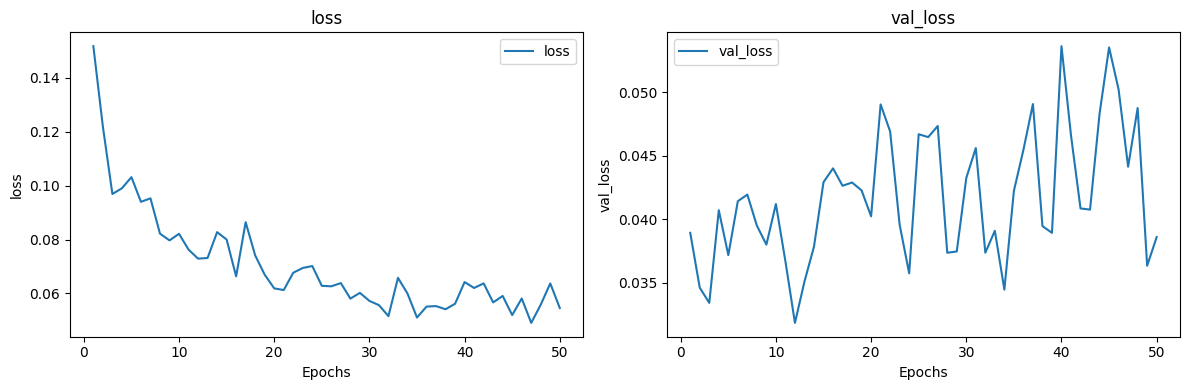

(<Figure size 1200x400 with 2 Axes>,
 array([<Axes: title={'center': 'loss'}, xlabel='Epochs', ylabel='loss'>,
        <Axes: title={'center': 'val_loss'}, xlabel='Epochs', ylabel='val_loss'>],
       dtype=object))

In [15]:
plot_hist(trainer.hist)

### Model Performance on Test Data


inference with test data:   0%|          | 0/196 [00:19<?, ?it/s]

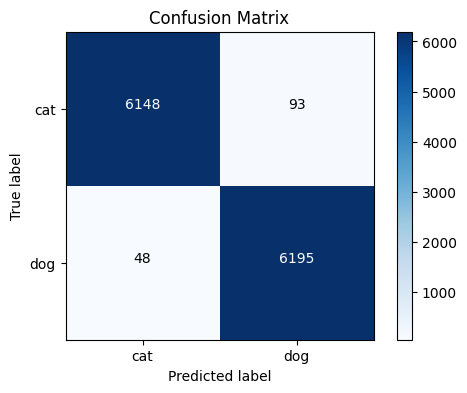

              precision    recall  f1-score   support

         cat       0.99      0.99      0.99      6241
         dog       0.99      0.99      0.99      6243

    accuracy                           0.99     12484
   macro avg       0.99      0.99      0.99     12484
weighted avg       0.99      0.99      0.99     12484



In [24]:
test_bs = 64
test_nw = 4
model = EffNet_B0_Clf(2).to(DEVICE)
model.load_state_dict(torch.load(CKPT_DIR / 'ckpt_20260311-13-59-32_50.pt', weights_only=False, map_location=DEVICE)['model_state_dict'])
dl_test = DataLoader(Subset(ds, idx_test), test_bs, shuffle=False, num_workers=test_nw, persistent_workers=True, pin_memory=True)
model.eval()
y_pred = torch.tensor(np.empty_like([])).to(DEVICE)
y_val = torch.tensor(np.empty_like([])).to(DEVICE)
with torch.inference_mode():
    for x, y in tqdm(dl_test, desc=f"inference with test data", leave=False):
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        y_pred = torch.concat((y_pred, model.predict(x)))
        y_val = torch.concat((y_val, y))

y_pred_np = y_pred.to('cpu').detach().numpy().astype('int')
y_val_np = y_val.to('cpu').detach().numpy().astype('int')

           
plot_confusion_matrix_and_report(y_val_np, y_pred_np, target_names=['cat', 'dog'])

* **Balanced accuracy** : (Recall_dog + Recall_cat) / 2 = 98.87%
* **Macro F1** : average of class F1s = 98.87%

The confusion matrix shows that the final model is on par with current best model while the model size is only ~15 MB.